In [8]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gymnasium', '-q'])
    import gymnasium as gym

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Fixed: Changed from 'Taxi-v3' to 'Taxi-v4' to match the latest gymnasium specifications
env = gym.make('Taxi-v4')
n_s = env.observation_space.n
n_a = env.action_space.n
print(f"Taxi-v4 Environment Initialized: {n_s} states, {n_a} actions.")


Taxi-v4 Environment Initialized: 500 states, 6 actions.


--- EXERCISE 1 RUNNING ---


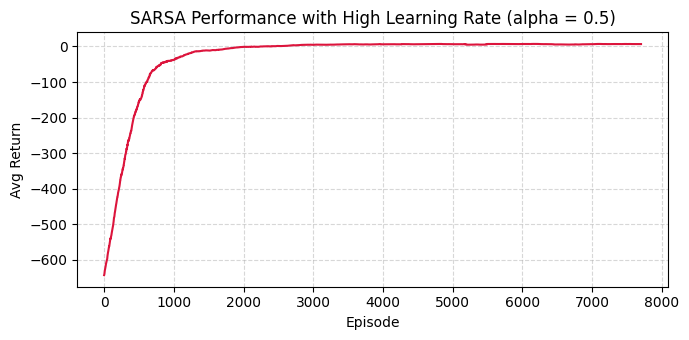

In [9]:
#Exercises-1-Change α from 0.1 to 0.5. Does SARSA learn faster or does it become unstable?
def sarsa_high_alpha(env, n_episodes=10_000, alpha=0.5, gamma=0.99, eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []

    def eps_greedy(s):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return np.argmax(Q[s])

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        ep_return = 0.0
        done = False

        while not done:
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            na = eps_greedy(ns)

            Q[s, a] += alpha * (r + gamma * Q[ns, na] * (not done) - Q[s, a])

            s, a = ns, na
            ep_return += r

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)

    return Q, returns_per_ep

print("--- EXERCISE 1 RUNNING ---")
_, returns_alpha_05 = sarsa_high_alpha(env, n_episodes=8000)

window = 300
rolling_alpha_05 = np.convolve(returns_alpha_05, np.ones(window)/window, mode='valid')

plt.figure(figsize=(7, 3.5))
plt.plot(rolling_alpha_05, color='crimson', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('SARSA Performance with High Learning Rate (alpha = 0.5)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- EXERCISE 2 RUNNING ---


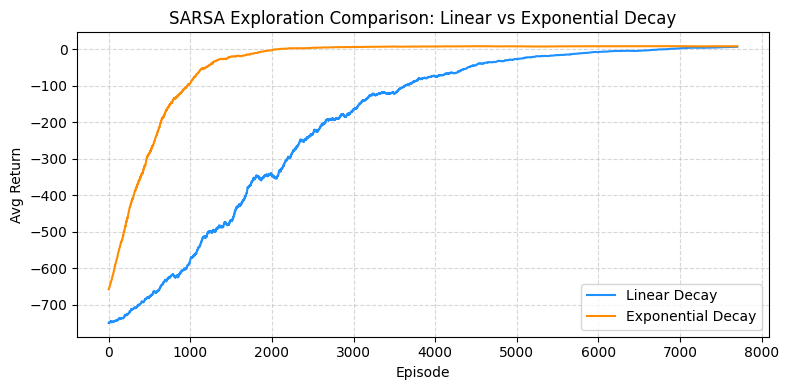

In [10]:
#2-Use a decaying ε schedule (start=1.0, end=0.01, linear decay). Compare to exponential decay.
def sarsa_decay_comparison(env, decay_type='linear', n_episodes=10_000, alpha=0.1, gamma=0.99, eps_start=1.0, eps_end=0.01):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []
    eps_decay_exp = 0.999

    def eps_greedy(s):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return np.argmax(Q[s])

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        ep_return = 0.0
        done = False

        while not done:
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            na = eps_greedy(ns)

            Q[s, a] += alpha * (r + gamma * Q[ns, na] * (not done) - Q[s, a])

            s, a = ns, na
            ep_return += r

        if decay_type == 'linear':
            eps = max(eps_end, eps_start - ep * (eps_start - eps_end) / n_episodes)
        elif decay_type == 'exponential':
            eps = max(eps_end, eps * eps_decay_exp)

        returns_per_ep.append(ep_return)

    return returns_per_ep

print("--- EXERCISE 2 RUNNING ---")
returns_linear = sarsa_decay_comparison(env, decay_type='linear', n_episodes=8000)
returns_exponential = sarsa_decay_comparison(env, decay_type='exponential', n_episodes=8000)

window = 300
rolling_linear = np.convolve(returns_linear, np.ones(window)/window, mode='valid')
rolling_exponential = np.convolve(returns_exponential, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(rolling_linear, color='dodgerblue', linewidth=1.5, label='Linear Decay')
plt.plot(rolling_exponential, color='darkorange', linewidth=1.5, label='Exponential Decay')
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('SARSA Exploration Comparison: Linear vs Exponential Decay')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [ ]:
#Challenge: implement SARSA(λ) with eligibility traces. Does it learn faster than SARSA(0)?
def sarsa_lambda(env, n_episodes=8000, alpha=0.1, gamma=0.99, lmbda=0.8, eps_start=1.0, eps_end=0.01, eps_decay=0.999):
    Q = np.zeros((n_s, n_a))
    eps = eps_start
    returns_per_ep = []

    def eps_greedy(s):
        if np.random.rand() < eps:
            return env.action_space.sample()
        return np.argmax(Q[s])

    for ep in range(n_episodes):
        s, _ = env.reset()
        a = eps_greedy(s)
        ep_return = 0.0
        done = False
        E = np.zeros((n_s, n_a))

        while not done:
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            na = eps_greedy(ns)

            td_error = r + gamma * Q[ns, na] * (not done) - Q[s, a]
            E[s, a] += 1.0

            # Vectorized update for active trajectories
            Q += alpha * td_error * E
            E = gamma * lmbda * E

            s, a = ns, na
            ep_return += r

        eps = max(eps_end, eps * eps_decay)
        returns_per_ep.append(ep_return)

    return Q, returns_per_ep

print("--- EXERCISE 3 RUNNING ---")
_, returns_sarsa_0 = sarsa_lambda(env, n_episodes=6000, lmbda=0.0)
_, returns_sarsa_lambda = sarsa_lambda(env, n_episodes=6000, lmbda=0.7)

window = 300
rolling_sarsa_0 = np.convolve(returns_sarsa_0, np.ones(window)/window, mode='valid')
rolling_sarsa_lambda = np.convolve(returns_sarsa_lambda, np.ones(window)/window, mode='valid')

plt.figure(figsize=(8, 4))
plt.plot(rolling_sarsa_0, color='gray', linewidth=1.5, label='SARSA(0) Baseline')
plt.plot(rolling_sarsa_lambda, color='purple', linewidth=1.5, label='SARSA(lambda=0.7) Traces')
plt.xlabel('Episode')
plt.ylabel('Avg Return')
plt.title('Learning Velocity Advantage: SARSA(0) vs SARSA(lambda)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


--- EXERCISE 3 RUNNING ---
